# Maven Toys — Sales & Revenue Analysis
### BI Consultant Project | Mexico Toy Store Chain

**Objective:** Identify which product categories, store locations, and store profiles drive the most revenue and profit — and provide a data-driven expansion recommendation for Maven Toys' new store openings.

**Dataset:** [Maven Toys Challenge](https://www.mavenanalytics.io/data-playground) — daily sales transactions, product details, store locations, and inventory levels across a fictitious Mexico-based toy store chain.

**Key Question:** Which store profile should Maven Toys replicate when expanding?

---
**Tools:** Python · pandas · SQLite · matplotlib · seaborn

## 1. Setup & Data Loading

All CSV files are loaded into an in-memory SQLite database. This allows SQL to handle joins and aggregations cleanly, mirroring a real world BI workflow where data lives in a relational database.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load raw data
path = '/content/drive/My Drive/Colab Notebooks/MavenToys/data/'

sales = pd.read_csv(path + 'sales.csv')
stores = pd.read_csv(path + 'stores.csv')
products = pd.read_csv(path + 'products.csv')
inventory = pd.read_csv(path + 'inventory.csv')
calendar = pd.read_csv(path + 'calendar.csv')

# Strip $ and convert to float
products['Product_Cost']  = products['Product_Cost'].str.replace('$', '', regex=False).astype(float)
products['Product_Price'] = products['Product_Price'].str.replace('$', '', regex=False).astype(float)

# Load into in-memory SQLite
conn = sqlite3.connect(':memory')

sales.to_sql('sales', conn, index=False, if_exists='replace')
stores.to_sql('stores', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
inventory.to_sql('inventory', conn, index=False, if_exists='replace')
calendar.to_sql('calendar', conn, index=False, if_exists='replace')


print('Tables loaded!')

Tables loaded!


## 2. Exploratory Data Analysis

### 2.1 Schema Overview

A quick look at the columns available across each table before joining anything.

In [3]:
print('SALES:', sales.columns.tolist())
print('STORES:', stores.columns.tolist())
print('PRODUCTS:', products.columns.tolist())
print('INVENTORY:', inventory.columns.tolist())
print('CALENDAR:', calendar.columns.tolist())

SALES: ['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units']
STORES: ['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Store_Open_Date']
PRODUCTS: ['Product_ID', 'Product_Name', 'Product_Category', 'Product_Cost', 'Product_Price']
INVENTORY: ['Store_ID', 'Product_ID', 'Stock_On_Hand']
CALENDAR: ['Date']


### 2.2 Shape & Null Check

Verifying row counts and checking for missing values across all tables before any analysis.

In [4]:
print('Sales: ', sales.shape)
print('Stores: ', stores.shape)
print('Products: ', products.shape)
print('Inventory: ', inventory.shape)
print('Calendar: ', calendar.shape)

Sales:  (829262, 5)
Stores:  (50, 5)
Products:  (35, 5)
Inventory:  (1593, 3)
Calendar:  (638, 1)


In [5]:
# Null value audit
for name, df in [('Sales', sales), ('Stores', stores), ('Products', products), ('Inventory', inventory)]:
    nulls = df.isnull().sum()
    if nulls.any():
      print(f'{name} nulls:\n', nulls[nulls > 0])
    else:
      print(f'{name}: no nulls')
    print()

Sales: no nulls

Stores: no nulls

Products: no nulls

Inventory: no nulls



### 2.3 Date Range

Understanding the time window of the dataset is important for interpreting trends and cohort analysis.

In [6]:
pd.read_sql("""
    SELECT
        MIN(Date) AS earliest_date,
        MAX(Date) AS latest_date,
        COUNT(DISTINCT Date) AS total_days
    FROM sales
""", conn)

,earliest_date,latest_date,total_days
0,2022-01-01,2023-09-30,638


### 2.4 Build the Base Table

Joining sales, products, and stores into a single clean table with revenue and profit calculated. This base table is used for all downstream analysis.

In [7]:
base = pd.read_sql("""
    SELECT
        sales.Sale_ID,
        sales.Date,
        sales.Units,
        stores.Store_ID,
        stores.Store_Name,
        stores.Store_City,
        stores.Store_Location,
        stores.Store_Open_Date,
        products.Product_ID,
        products.Product_Name,
        products.Product_Category,
        products.Product_Cost,
        products.Product_Price,
        ROUND(sales.Units * products.Product_Price, 2) AS revenue,
        ROUND(sales.Units * (products.Product_Price - products.Product_Cost), 2) AS profit,
        ROUND((products.Product_Price - products.Product_Cost) / products.Product_Price * 100, 2) AS margin_pct
    FROM sales
    JOIN stores   ON sales.Store_ID   = stores.Store_ID
    JOIN products ON sales.Product_ID = products.Product_ID
""", conn)

# Register base table in SQLite for downstream queries
base.to_sql('base', conn, index=False, if_exists='replace')

print(f'Base table: {base.shape[0]:,} rows, {base.shape[1]} columns')
base.head()

Base table: 829,262 rows, 16 columns


,Sale_ID,Date,Units,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price,revenue,profit,margin_pct
0,1,2022-01-01,1,24,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,4,Chutes & Ladders,Games,9.99,12.99,12.99,3.0,23.09
1,2,2022-01-01,1,28,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,1,Action Figure,Toys,9.99,15.99,15.99,6.0,37.52
2,3,2022-01-01,1,6,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,8,Deck Of Cards,Games,3.99,6.99,6.99,3.0,42.92
3,4,2022-01-01,1,48,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,7,Dart Gun,Sports & Outdoors,11.99,15.99,15.99,4.0,25.02
4,5,2022-01-01,1,44,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,18,Lego Bricks,Toys,34.99,39.99,39.99,5.0,12.50


## 3. Product & Category Performance

Which product categories drive the most revenue and profit — and is this consistent across store locations? Understanding category-level performance is the foundation for stocking decisions in new stores.

In [8]:
category_perf = pd.read_sql("""
    SELECT
        Product_Category,
        SUM(revenue) AS total_revenue,
        SUM(profit) AS total_profit,
        ROUND(AVG(margin_pct), 2) AS avg_margin_pct,
        SUM(Units) AS total_units
    FROM base
    GROUP BY Product_Category
    ORDER BY total_profit DESC
""", conn)

print(category_perf)

    Product_Category  total_revenue  total_profit  avg_margin_pct  total_units
0               Toys   5.093241e+06     1079527.0           25.05       267200
1        Electronics   2.246771e+06     1001437.0           45.86       134075
2       Art & Crafts   2.705364e+06      753354.0           32.84       325574
3              Games   2.226836e+06      673993.0           36.09       194673
4  Sports & Outdoors   2.172360e+06      505718.0           22.08       169043


**Key Insights:**

- **Electronics** has the highest margin at 46% — nearly double that of Sports & Outdoors (22%)
- **Toys** generates the most total revenue and units but ranks second-lowest on margin — growth is volume-driven, not efficiency-driven
- **Electronics delivers nearly as much total profit as Toys** despite selling less than half the units — a strong signal for prioritising shelf space in new stores
- **Sports & Outdoors** is the weakest category on both profit and margin — the lowest priority for new store inventory

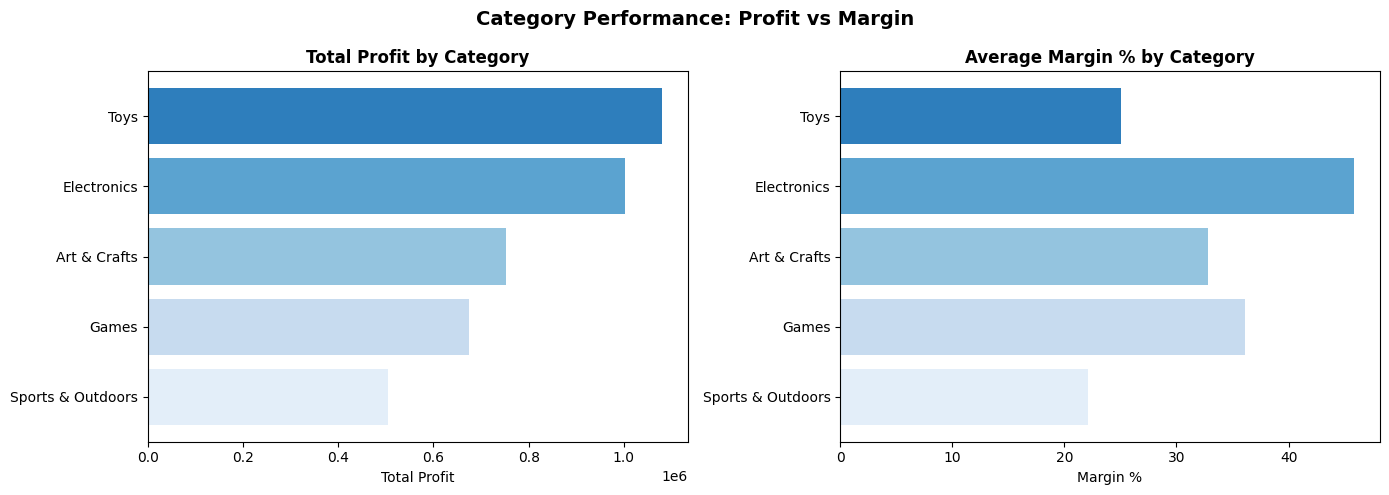

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(category_perf)))

# Total profit by category
axes[0].barh(category_perf['Product_Category'], category_perf['total_profit'], color=colors)
axes[0].set_title('Total Profit by Category', fontweight='bold')
axes[0].set_xlabel('Total Profit')
axes[0].invert_yaxis()

# Avg margin % by category
axes[1].barh(category_perf['Product_Category'], category_perf['avg_margin_pct'], color=colors)
axes[1].set_title('Average Margin % by Category', fontweight='bold')
axes[1].set_xlabel('Margin %')
axes[1].invert_yaxis()

plt.suptitle('Category Performance: Profit vs Margin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Store & Regional Performance

Which stores and cities are the most profitable? Identifying top-performing store profiles — by city and location type — directly informs where Maven Toys should open next.

In [10]:
store_perf = pd.read_sql("""
    SELECT
        Store_Name,
        Store_City,
        Store_Location,
        SUM(revenue) AS total_revenue,
        SUM(profit) AS total_profit,
        ROUND(AVG(margin_pct), 2)
    FROM base
    GROUP BY Store_Name, Store_City, Store_Location
    ORDER BY total_profit DESC
""", conn)

print('Top 10 stores by profit:')
print(store_perf.head(10))

Top 10 stores by profit:
                      Store_Name        Store_City Store_Location  \
0  Maven Toys Ciudad de Mexico 2  Cuidad de Mexico        Airport   
1       Maven Toys Guadalajara 3       Guadalajara        Airport   
2  Maven Toys Ciudad de Mexico 1  Cuidad de Mexico       Downtown   
3         Maven Toys Monterrey 2         Monterrey       Downtown   
4            Maven Toys Toluca 1            Toluca       Downtown   
5       Maven Toys Guadalajara 4       Guadalajara       Downtown   
6        Maven Toys Hermosillo 3        Hermosillo     Commercial   
7          Maven Toys Mexicali 1          Mexicali     Commercial   
8          Maven Toys Saltillo 1          Saltillo       Downtown   
9  Maven Toys Ciudad de Mexico 3  Cuidad de Mexico    Residential   

   total_revenue  total_profit  ROUND(AVG(margin_pct), 2)  
0      554553.43      169856.0                      33.03  
1      449354.91      121571.0                      29.95  
2      433556.21      111296.0     

In [11]:
# Performance by location type

location_perf = pd.read_sql("""
    SELECT
      Store_Location,
      COUNT(DISTINCT Store_ID) AS num_stores,
      SUM(revenue) AS total_revenue,
      SUM(profit) AS total_profit,
      ROUND(SUM(profit) / COUNT(DISTINCT Store_ID), 2) AS avg_profit_per_store
    FROM base
    GROUP BY Store_Location
    ORDER BY avg_profit_per_store DESC
""", conn)

print(location_perf)

  Store_Location  num_stores  total_revenue  total_profit  \
0        Airport           3   1.289723e+06      378049.0   
1       Downtown          29   8.219596e+06     2248728.0   
2     Commercial          12   3.279140e+06      926864.0   
3    Residential           6   1.656114e+06      460388.0   

   avg_profit_per_store  
0             126016.33  
1              77542.34  
2              77238.67  
3              76731.33  


**Key Insights:**

- **Airport stores average 126,016 profit per store** — 63% higher than any other location type
- **Downtown, Commercial, and Residential** are within 1% of each other at ~77k avg profit per store — location type alone does not differentiate them
- With only 3 Airport stores currently operating, this is the most underleveraged location type in the portfolio — representing a clear expansion opportunity

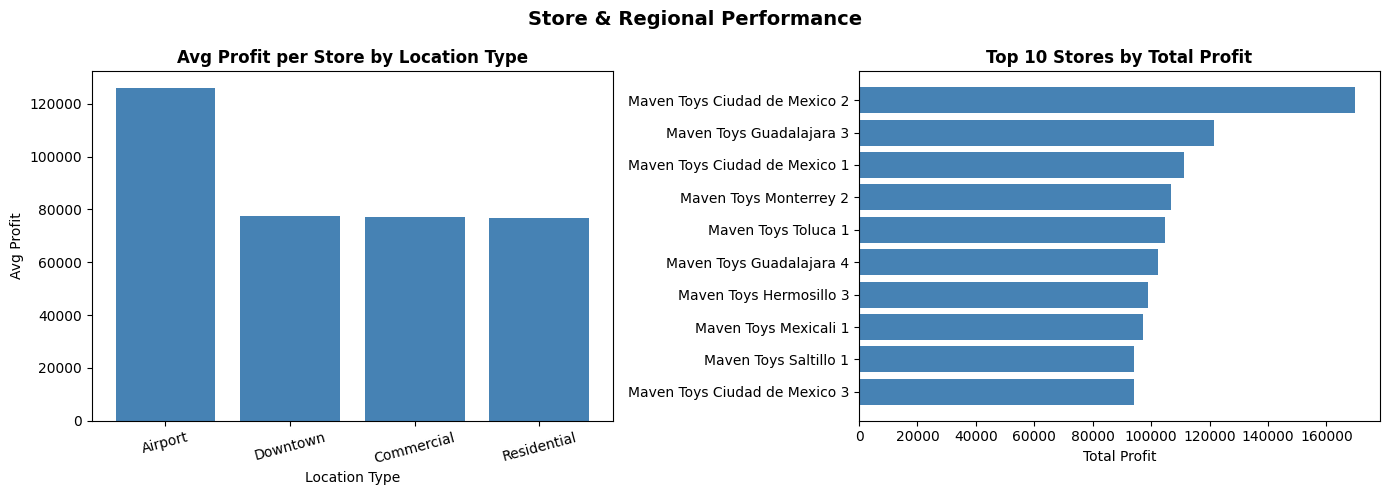

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg profit per store by location type
axes[0].bar(location_perf['Store_Location'], location_perf['avg_profit_per_store'], color='steelblue')
axes[0].set_title('Avg Profit per Store by Location Type', fontweight='bold')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Avg Profit')
axes[0].tick_params(axis='x', rotation=15)

# Top 10 stores by total profit
top10 = store_perf.head(10)
axes[1].barh(top10['Store_Name'], top10['total_profit'], color='steelblue')
axes[1].set_title('Top 10 Stores by Total Profit', fontweight='bold')
axes[1].set_xlabel('Total Profit')
axes[1].invert_yaxis()

plt.suptitle('Store & Regional Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights:**

- **Ciudad de Mexico** appears 3 times in the top 10 — it is the strongest city in the portfolio by total profit
- **Guadalajara** (2 stores) and **Monterrey** (1 store) are the next strongest markets
- The top store, Maven Toys Ciudad de Mexico 2, generates nearly double the profit of the 10th-ranked store — highlighting the outsized value of the highest-performing locations

Combined with the location type analysis, the data points clearly to **Airport stores in Ciudad de Mexico and Guadalajara** as the highest-value expansion profile.

## 5. Seasonal Trends

Are there seasonal patterns in revenue that should inform when new stores open and when to stock up? Identifying peak periods helps Maven Toys time expansion decisions and inventory builds.

In [13]:
monthly = pd.read_sql("""
    SELECT
        strftime('%Y-%m', Date) AS month,
        ROUND(SUM(revenue), 2) AS total_revenue,
        ROUND(SUM(profit), 2) AS total_profit,
        SUM(Units) AS total_units
    FROM base
    GROUP BY month
    ORDER BY month
""", conn)

print(monthly)

      month  total_revenue  total_profit  total_units
0   2022-01      542554.91      167126.0        38009
1   2022-02      541351.65      161861.0        36935
2   2022-03      589485.19      173992.0        39981
3   2022-04      681072.98      190099.0        47102
4   2022-05      672369.90      186894.0        46910
5   2022-06      661980.22      189815.0        47178
6   2022-07      556034.23      176922.0        46177
7   2022-08      489422.73      158931.0        39927
8   2022-09      585844.04      166397.0        42196
9   2022-10      623874.39      178799.0        47861
10  2022-11      661304.15      192873.0        51185
11  2022-12      877203.69      246078.0        66031
12  2023-01      747196.22      205074.0        56478
13  2023-02      722632.19      189314.0        54581
14  2023-03      883515.64      231909.0        69336
15  2023-04      827691.07      215096.0        65593
16  2023-05      825319.49      210347.0        63851
17  2023-06      808299.25  

**Key Insights:**

- **December is the peak month** — 877k revenue in 2022, the highest single month in the dataset, driven by Christmas demand
- **August is consistently the weakest month** across both years — revenue drops ~17% below the annual average
- **2023 outperforms 2022 in every single month** — the business is growing year over year across all store types and categories
- **March spikes in both years** — likely driven by Easter and spring demand patterns in Mexico
- *Implication for expansion:* New stores should open by October at the latest to capture the December peak from day one

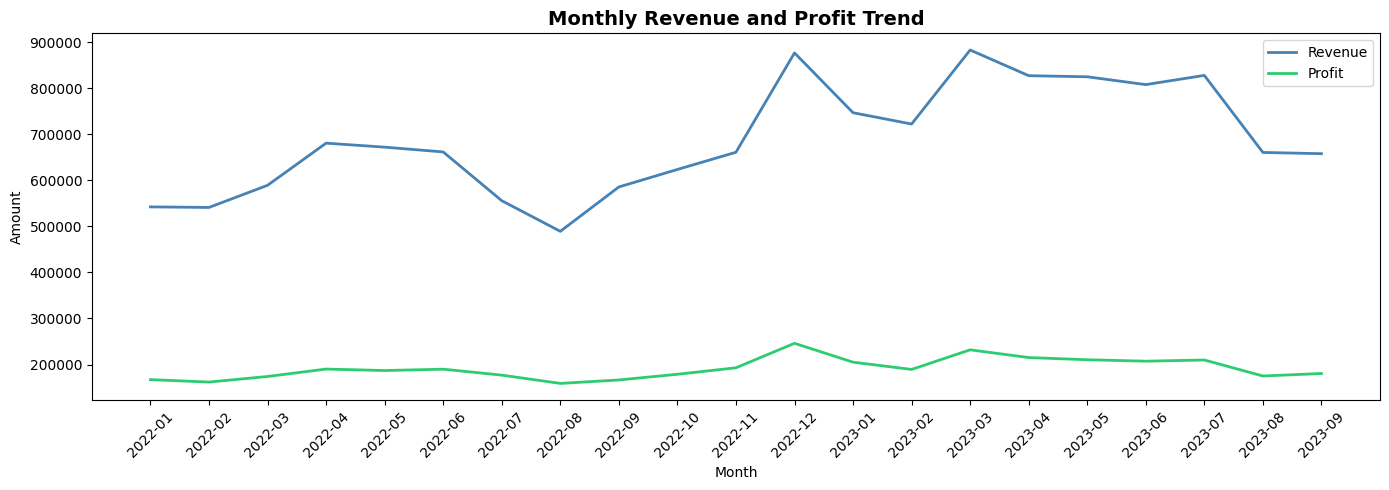

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['month'], monthly['total_revenue'], color='steelblue', linewidth=2, label='Revenue')
ax.plot(monthly['month'], monthly['total_profit'],  color='#2ecc71',   linewidth=2, label='Profit')

ax.set_title('Monthly Revenue and Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The consistent gap between revenue and profit reflects an overall margin of ~28% across the business. Crucially, the two lines move in parallel — margins remain stable through both peak and off-peak months, indicating no seasonal deterioration in profitability.

## 6. Store Ramp-Up Cohort Analysis

All stores in the dataset opened between 1992 and 2016 — predating the sales data which begins in January 2022. Rather than tracking individual store ramp-up, stores are grouped into opening cohorts to compare how different eras of expansion have performed over the analysis period.

In [15]:
cohort_data = pd.read_sql("""
    SELECT * FROM (
        SELECT
            Store_ID,
            Store_Name,
            Store_Location,
            Store_City,
            Store_Open_Date,
            Date,
            revenue,
            profit,
            CASE
                WHEN strftime('%Y', Store_Open_Date) < '2000' THEN 'Pre-2000'
                WHEN strftime('%Y', Store_Open_Date) < '2005' THEN '2000-2004'
                WHEN strftime('%Y', Store_Open_Date) < '2010' THEN '2005-2009'
                WHEN strftime('%Y', Store_Open_Date) < '2015' THEN '2010-2014'
                ELSE '2015+'
            END AS open_cohort
        FROM base
    )
""", conn)

# Revenue by cohort and month
rampup = cohort_data.groupby(['open_cohort', pd.to_datetime(cohort_data['Date']).dt.to_period('M')])['revenue'].sum().reset_index()
rampup_pivot = rampup.pivot(index='Date', columns='open_cohort', values='revenue')

print(rampup_pivot.round(2))

open_cohort  2000-2004  2005-2009  2010-2014      2015+  Pre-2000
Date                                                             
2022-01       85990.64  126687.58  240811.26   54155.53  34909.90
2022-02       77723.13  124095.68  246035.23   56045.34  37452.27
2022-03       85056.24  128044.87  272922.39   71628.91  31832.78
2022-04       90812.41  141836.01  309357.57  100735.57  38331.42
2022-05       81418.52  147238.98  316562.33   82705.45  44444.62
2022-06       71677.26  149964.14  301092.12   98792.47  40454.23
2022-07       66023.85  119978.41  263685.09   74323.81  32023.07
2022-08       62633.65  114783.80  215711.32   67622.32  28671.64
2022-09       70136.74  126518.87  279592.74   76719.37  32876.32
2022-10       81631.01  136028.37  293880.74   75777.31  36556.96
2022-11       87143.36  150213.14  311586.22   75294.99  37066.44
2022-12      109328.88  211879.36  396738.42  111335.06  47921.97
2023-01      100630.82  177419.30  346629.84   80786.17  41730.09
2023-02   

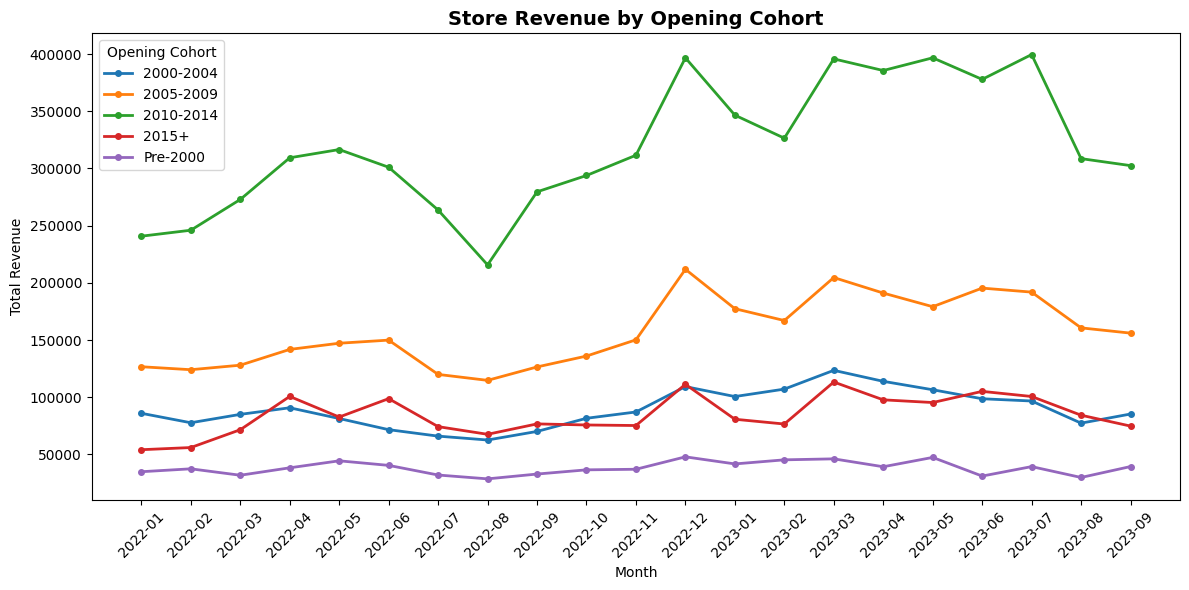

In [16]:
rampup_pivot.index = rampup_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 6))

for col in rampup_pivot.columns:
    ax.plot(rampup_pivot.index, rampup_pivot[col], linewidth=2, label=col, marker='o', markersize=4)

ax.set_title('Store Revenue by Opening Cohort', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.legend(title='Opening Cohort')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
cohort_store_avg = pd.read_sql("""
    SELECT * FROM (
        SELECT
            CASE
                WHEN strftime('%Y', Store_Open_Date) < '2000' THEN 'Pre-2000'
                WHEN strftime('%Y', Store_Open_Date) < '2005' THEN '2000-2004'
                WHEN strftime('%Y', Store_Open_Date) < '2010' THEN '2005-2009'
                WHEN strftime('%Y', Store_Open_Date) < '2015' THEN '2010-2014'
                ELSE '2015+'
            END AS open_cohort,
            COUNT(DISTINCT Store_ID)                                    AS num_stores,
            ROUND(SUM(revenue), 2)                                      AS total_revenue,
            ROUND(SUM(revenue) / COUNT(DISTINCT Store_ID), 2)          AS avg_revenue_per_store,
            ROUND(SUM(profit), 2)                                       AS total_profit,
            ROUND(SUM(profit) / COUNT(DISTINCT Store_ID), 2)           AS avg_profit_per_store
        FROM base
        GROUP BY open_cohort
    )
    ORDER BY avg_profit_per_store DESC
""", conn)

print(cohort_store_avg)

  open_cohort  num_stores  total_revenue  avg_revenue_per_store  total_profit  \
0   2000-2004           6     1879557.33              313259.55      530933.0   
1   2010-2014          23     6687976.49              290781.59     1901033.0   
2       2015+           6     1773977.39              295662.90      472352.0   
3   2005-2009          12     3300824.09              275068.67      890545.0   
4    Pre-2000           3      802237.05              267412.35      219166.0   

   avg_profit_per_store  
0              88488.83  
1              82653.61  
2              78725.33  
3              74212.08  
4              73055.33  


In [18]:
category_perf = pd.read_sql("""
    SELECT
        Product_Category,
        ROUND(SUM(revenue), 2)                          AS total_revenue,
        ROUND(SUM(profit), 2)                           AS total_profit,
        ROUND(SUM(profit) / SUM(revenue) * 100, 2)     AS margin_pct,
        SUM(Units)                                      AS total_units
    FROM base
    GROUP BY Product_Category
    ORDER BY total_profit DESC
""", conn)

print(category_perf)

    Product_Category  total_revenue  total_profit  margin_pct  total_units
0               Toys     5093241.00     1079527.0       21.20       267200
1        Electronics     2246771.25     1001437.0       44.57       134075
2       Art & Crafts     2705364.26      753354.0       27.85       325574
3              Games     2226836.27      673993.0       30.27       194673
4  Sports & Outdoors     2172359.57      505718.0       23.28       169043


**Key Insight:**

The 2010-2014 cohort dominates total revenue, but this is largely explained by scale — it contains 23 stores compared to 3–6 in every other cohort. Normalising by store count reveals a different picture: the **2000-2004 cohort generates the highest average profit per store at 88,489**, suggesting that the location choices made during that period were particularly strong. The 2015+ cohort ranks third on a per-store basis despite being the newest — newer does not mean more efficient.